In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
plt.style.use('default')
pd.set_option('display.max_columns', None)

In [8]:
fund_df = pd.read_csv("../data/raw/01_fund_master.csv")
nav_df = pd.read_csv("../data/processed/clean_nav_history.csv")
aum_df = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")
sip_df = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")
category_df = pd.read_csv("../data/raw/05_category_inflows.csv")
folio_df = pd.read_csv("../data/raw/06_industry_folio_count.csv")
perf_df = pd.read_csv("../data/processed/clean_scheme_performance.csv")
tx_df = pd.read_csv("../data/processed/clean_transactions.csv")
holding_df = pd.read_csv("../data/raw/09_portfolio_holdings.csv")
benchmark_df = pd.read_csv("../data/raw/10_benchmark_indices.csv")

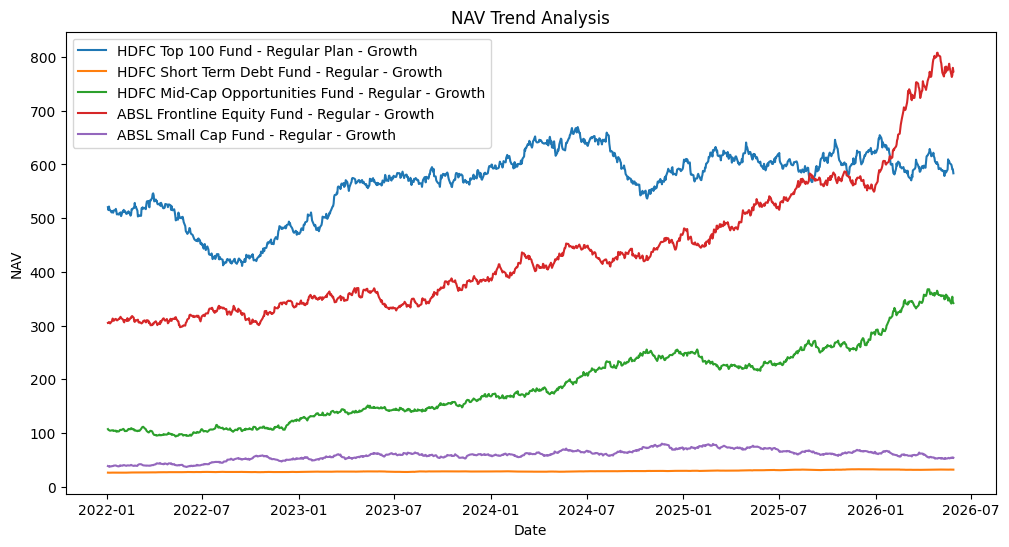

In [11]:
nav_df["date"] = pd.to_datetime(nav_df["date"])
nav_df = nav_df.merge(fund_df[["amfi_code","scheme_name"]], on="amfi_code")
selected_funds = nav_df["scheme_name"].unique()[:5]
plt.figure(figsize=(12,6))
for fund in selected_funds:
    temp = nav_df[nav_df["scheme_name"] == fund]
    plt.plot(temp["date"], temp["nav"], label=fund)
plt.title("NAV Trend Analysis")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.legend()
plt.show()

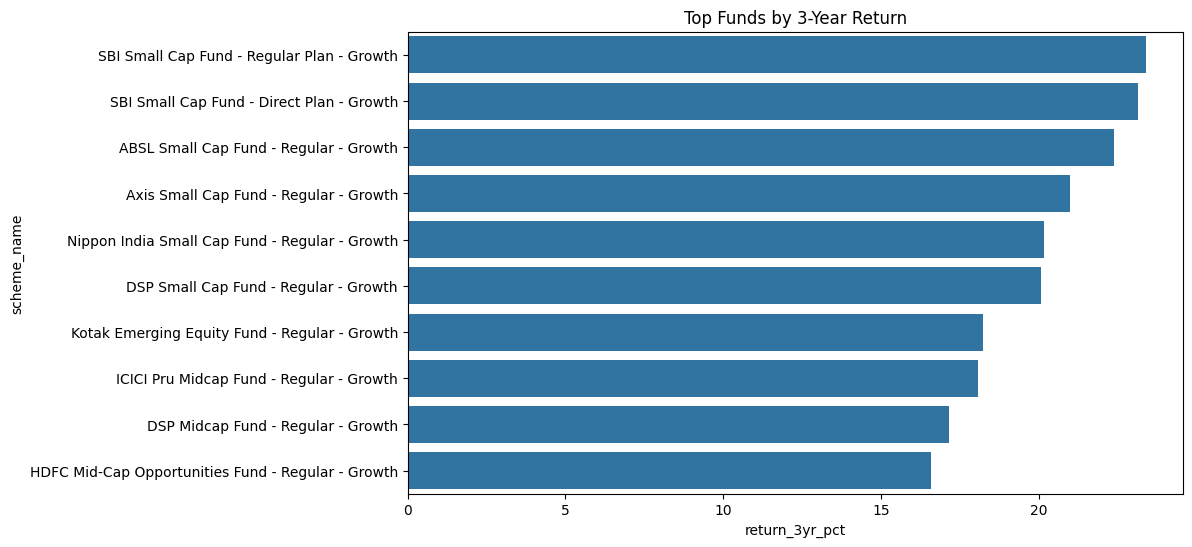

In [12]:
top_returns=(perf_df.sort_values("return_3yr_pct", ascending=False).head(10))
plt.figure(figsize=(10,6))
sns.barplot(data=top_returns, x="return_3yr_pct", y="scheme_name")
plt.title("Top Funds by 3-Year Return")
plt.show()

In [15]:
aum_df["date"] = pd.to_datetime(aum_df["date"])
aum_df["year"] = aum_df["date"].dt.year

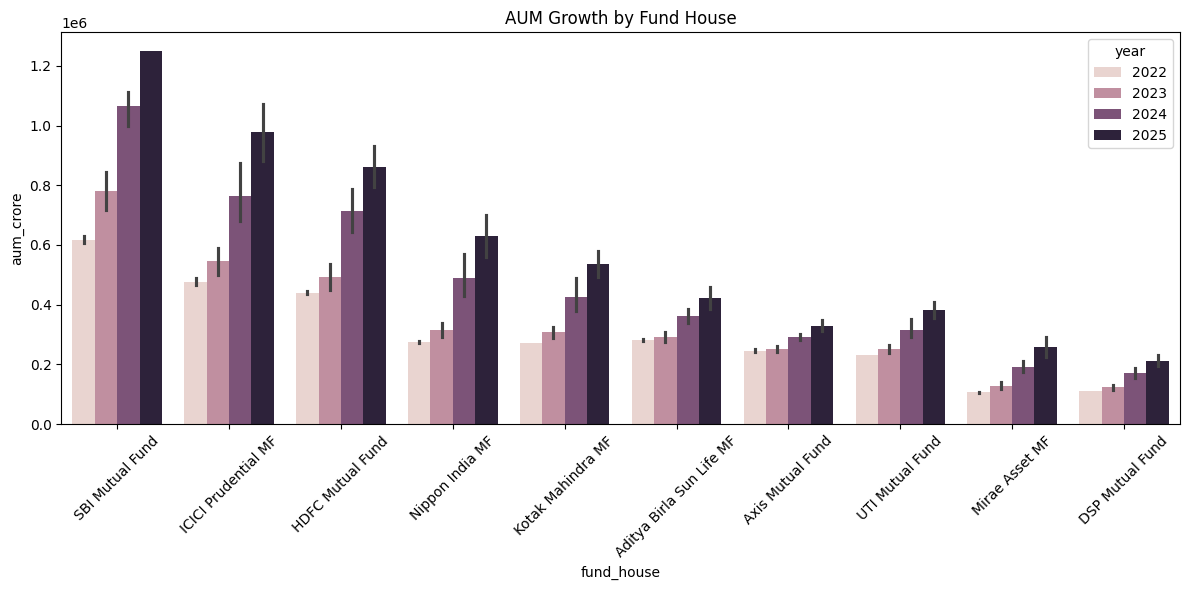

In [16]:
plt.figure(figsize=(12,6))
sns.barplot(data=aum_df, x="fund_house", y="aum_crore", hue="year")
plt.xticks(rotation=45)
plt.title("AUM Growth by Fund House")
plt.tight_layout()
plt.show()

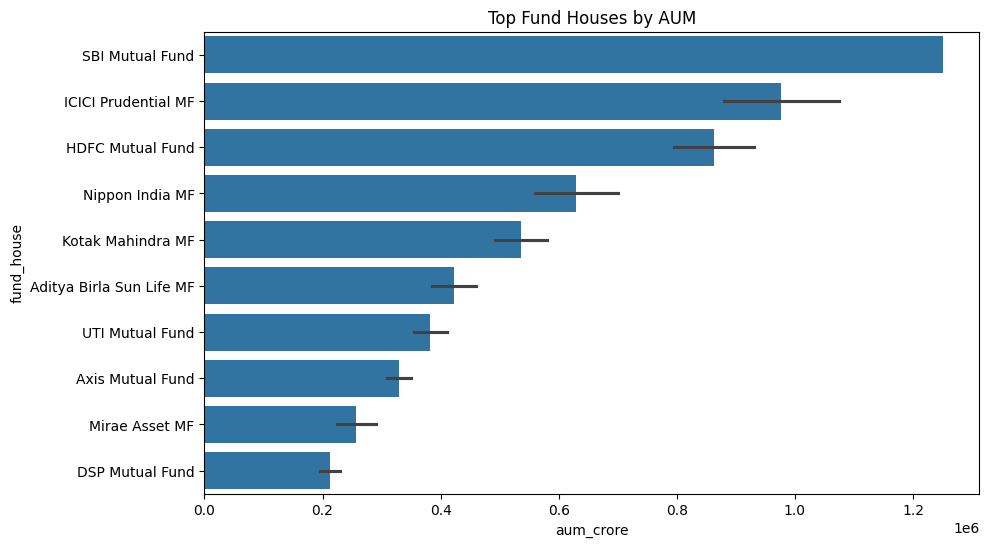

In [17]:
latest_year = aum_df["year"].max()
latest = aum_df[
    aum_df["year"] == latest_year
]
latest = latest.sort_values(
    "aum_crore",
    ascending=False
)
plt.figure(figsize=(10,6))
sns.barplot(
    data=latest,
    x="aum_crore",
    y="fund_house"
)
plt.title("Top Fund Houses by AUM")
plt.show()

In [18]:
print("SIP")
print(sip_df.columns.tolist())

print("\nCATEGORY")
print(category_df.columns.tolist())

print("\nFOLIO")
print(folio_df.columns.tolist())

print("\nHOLDING")
print(holding_df.columns.tolist())

SIP
['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']

CATEGORY
['month', 'category', 'net_inflow_crore']

FOLIO
['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']

HOLDING
['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


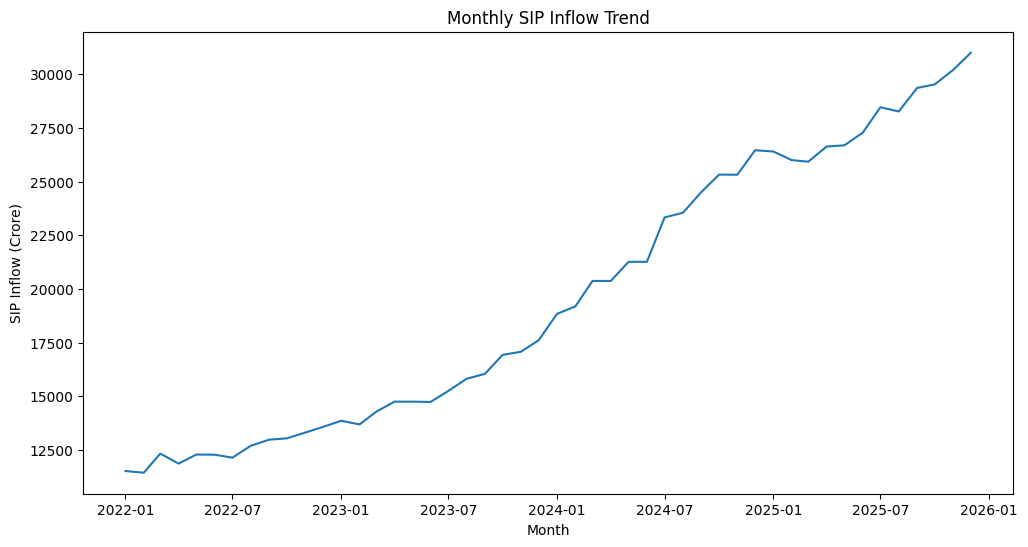

In [19]:
sip_df["month"] = pd.to_datetime(sip_df["month"])

plt.figure(figsize=(12,6))

plt.plot(
    sip_df["month"],
    sip_df["sip_inflow_crore"]
)

plt.title("Monthly SIP Inflow Trend")
plt.xlabel("Month")
plt.ylabel("SIP Inflow (Crore)")
plt.show()

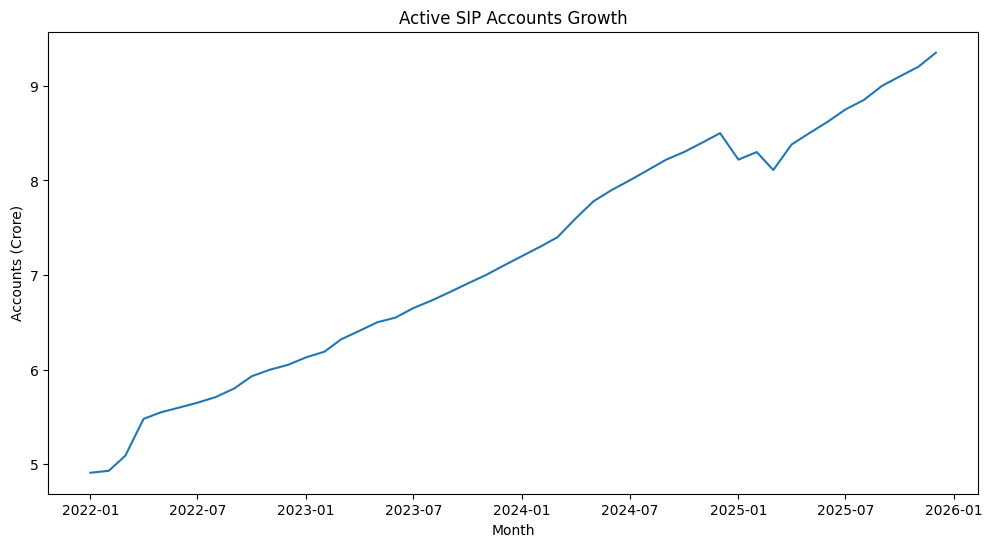

In [20]:
plt.figure(figsize=(12,6))

plt.plot(
    sip_df["month"],
    sip_df["active_sip_accounts_crore"]
)

plt.title("Active SIP Accounts Growth")
plt.xlabel("Month")
plt.ylabel("Accounts (Crore)")
plt.show()

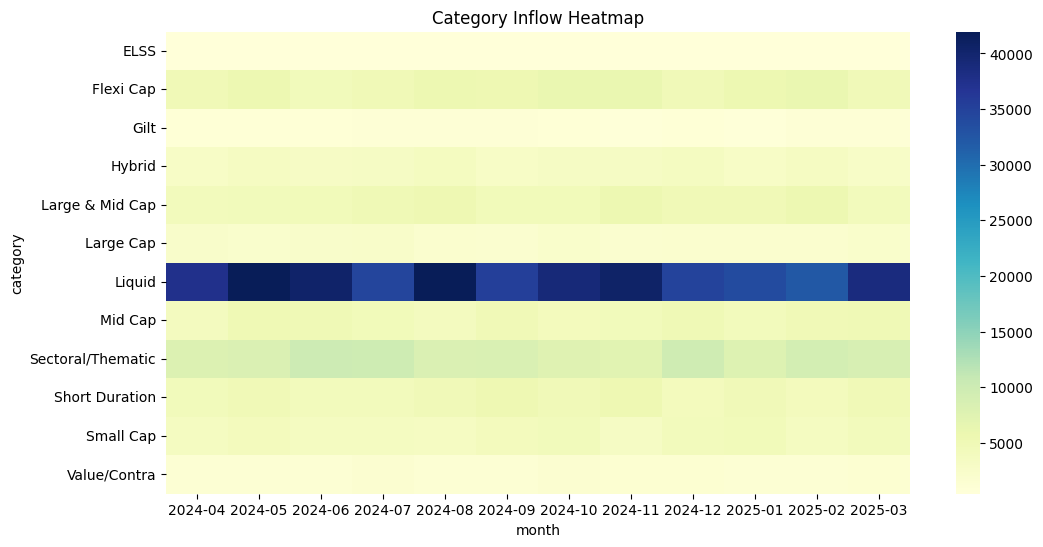

In [21]:
pivot = category_df.pivot_table(
    values="net_inflow_crore",
    index="category",
    columns="month"
)

plt.figure(figsize=(12,6))

sns.heatmap(
    pivot,
    cmap="YlGnBu"
)

plt.title("Category Inflow Heatmap")

plt.show()

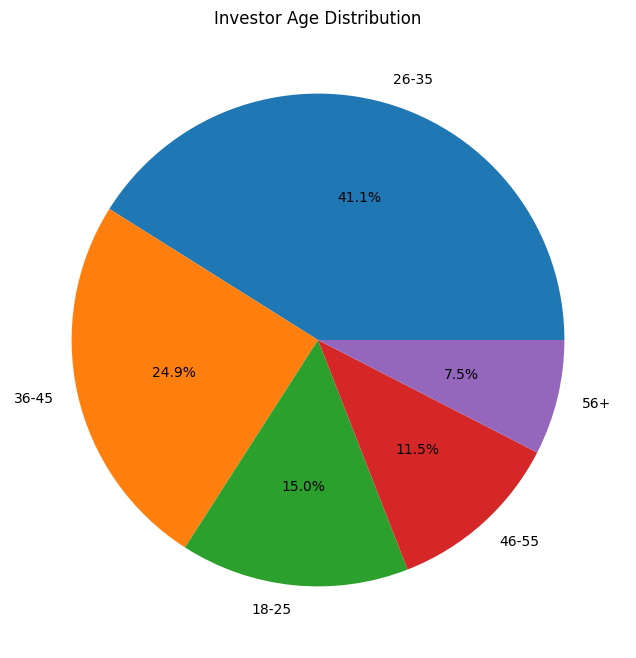

In [22]:
plt.figure(figsize=(8,8))

tx_df["age_group"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Investor Age Distribution")

plt.show()

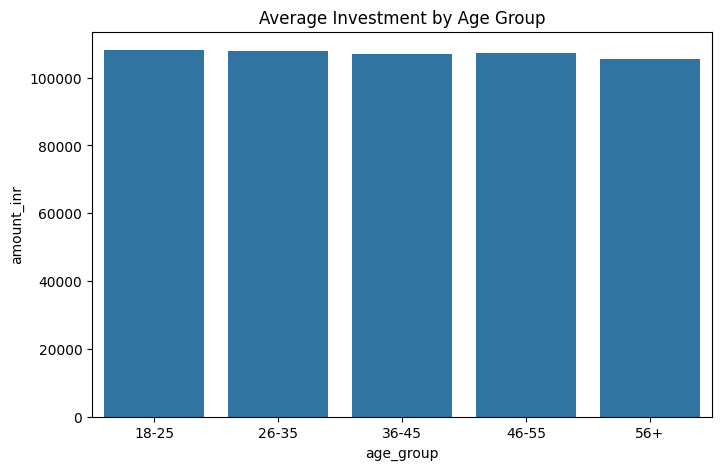

In [23]:
avg_age = (
    tx_df.groupby("age_group")
    ["amount_inr"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=avg_age,
    x="age_group",
    y="amount_inr"
)

plt.title("Average Investment by Age Group")

plt.show()

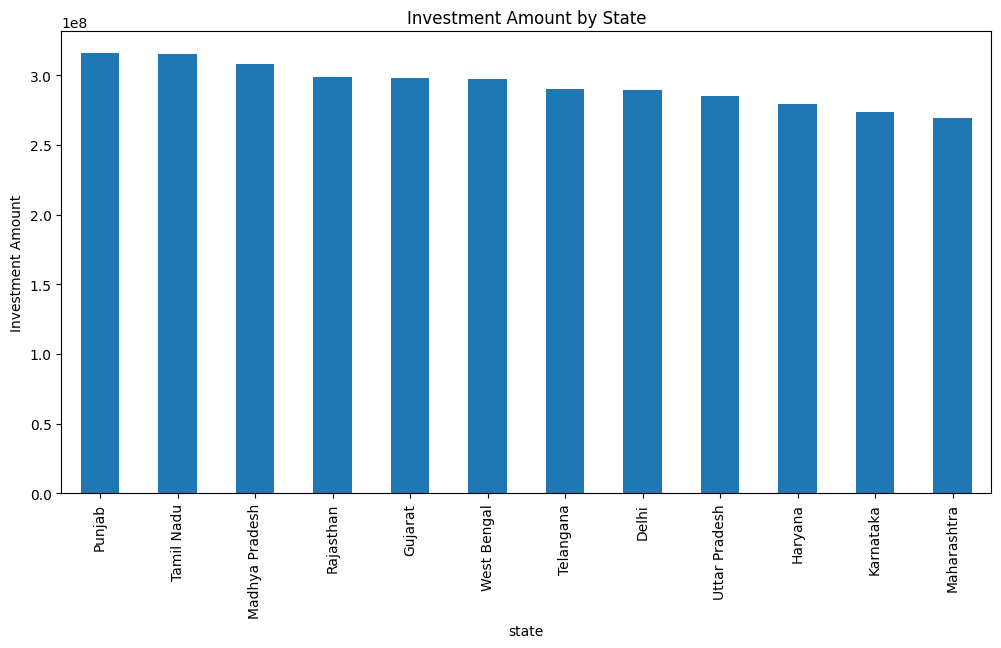

In [24]:
state_data = (
    tx_df.groupby("state")
    ["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

state_data.plot(kind="bar")

plt.title("Investment Amount by State")

plt.ylabel("Investment Amount")

plt.show()

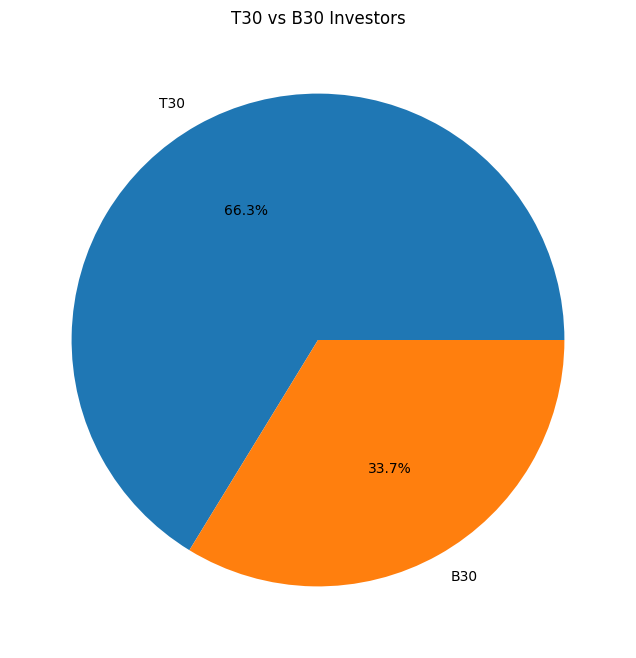

In [25]:
plt.figure(figsize=(8,8))

tx_df["city_tier"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("T30 vs B30 Investors")

plt.show()

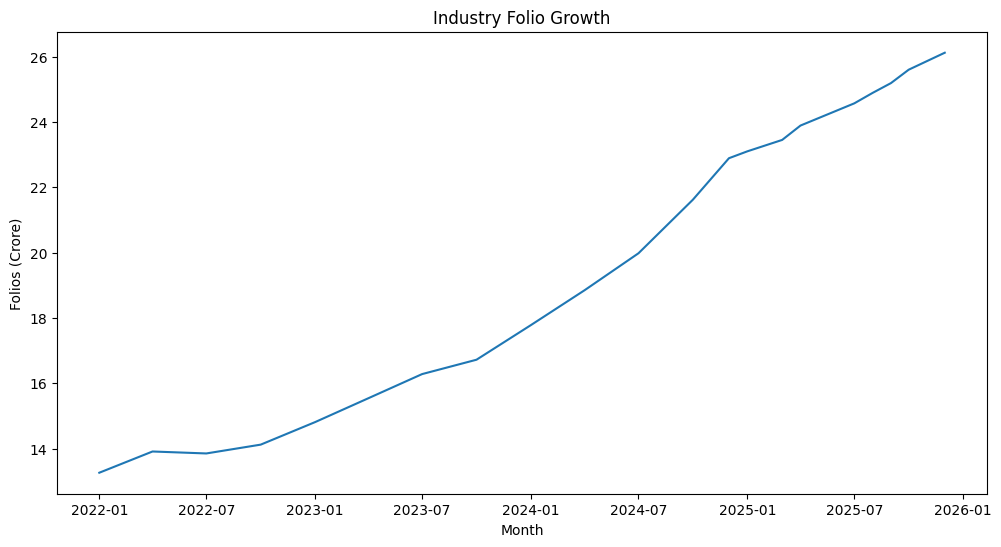

In [26]:
folio_df["month"] = pd.to_datetime(
    folio_df["month"]
)

plt.figure(figsize=(12,6))

plt.plot(
    folio_df["month"],
    folio_df["total_folios_crore"]
)

plt.title("Industry Folio Growth")

plt.xlabel("Month")
plt.ylabel("Folios (Crore)")

plt.show()

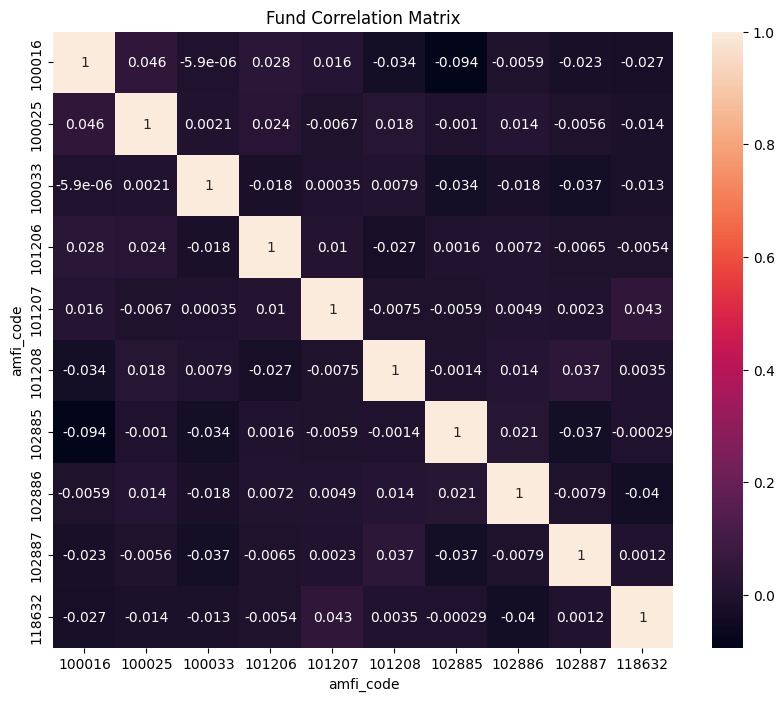

In [27]:
sample_funds = nav_df["amfi_code"].unique()[:10]
corr_df = nav_df[
    nav_df["amfi_code"].isin(sample_funds)
]
pivot = corr_df.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)
returns = pivot.pct_change()
plt.figure(figsize=(10,8))
sns.heatmap(
    returns.corr(),
    annot=True
)
plt.title("Fund Correlation Matrix")
plt.show()

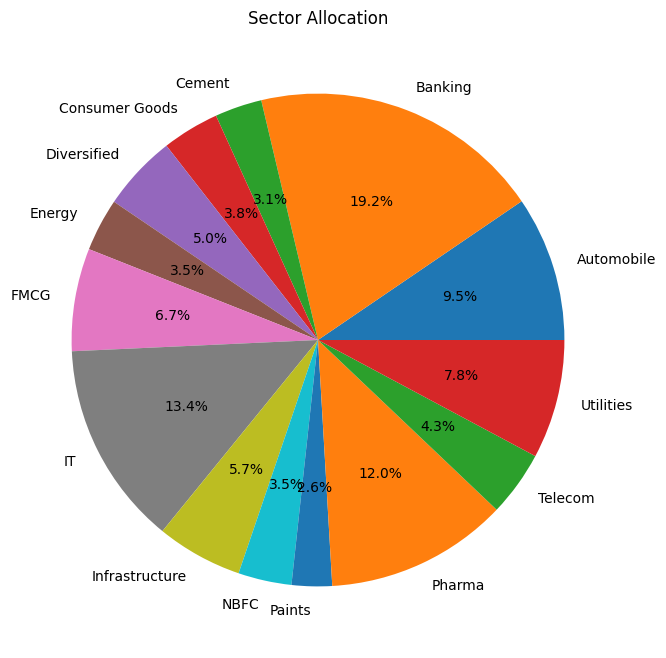

In [28]:
sector=(holding_df.groupby("sector")["weight_pct"].sum())
plt.figure(figsize=(8,8))
sector.plot(kind="pie", autopct="%1.1f%%")
plt.title("Sector Allocation")
plt.show()

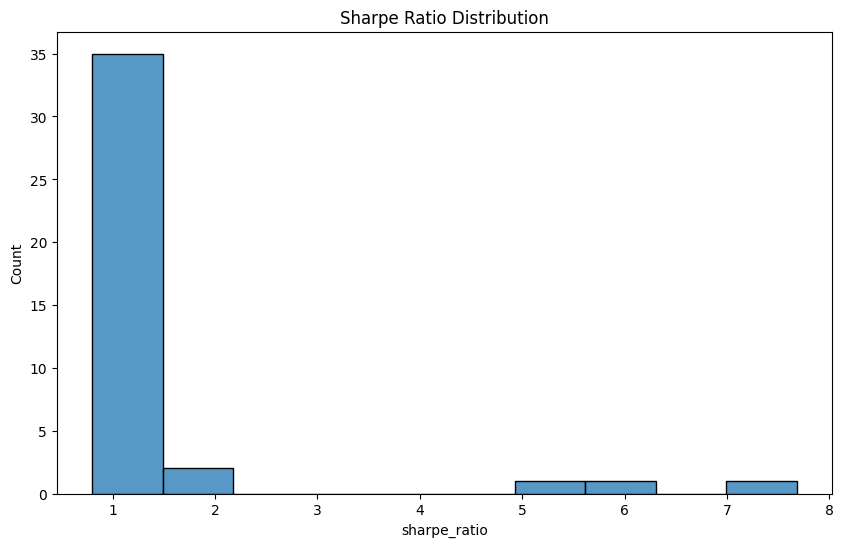

In [29]:
plt.figure(figsize=(10,6))
sns.histplot(perf_df["sharpe_ratio"], bins=10)
plt.title("Sharpe Ratio Distribution")
plt.show()

In [30]:
print("EDA Completed Successfully")
print("Total Charts Generated: 16")

EDA Completed Successfully
Total Charts Generated: 16
